# 📘 AI/ML Assignment 3
## Supervised Learning Models in Practice

**Total Marks: 100**  
**Submission Format:** Single Jupyter Notebook (`.ipynb`)

---
## 📌 General Instructions (Read Carefully)

- This assignment covers **Modules 13–18**.
- Use **Python and scikit-learn only**.
- Do NOT use AutoML, deep learning, or external ML libraries.
- Fix `random_state=42` wherever applicable.
- Plots must be labeled and readable.
- Do not delete or rename cells.

***Classification Dataset:*** https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data

***Regresssion Dataset:*** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 🔧 TODO 0: Environment Setup (5 Marks)
**Marks Breakdown:**
- Correct imports (3)
- Clean setup, no unused imports (2)


In [228]:
# TODO: Import all necessary libraries here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, mean_squared_error, r2_score

# 🔵 PART A: Regression Task (45 Marks)
You will work with the provided **regression dataset**.


## TODO A1: Dataset Loading and Understanding (5 Marks)
**You must:**
- Load the dataset
- Show shape and column names
- Identify target variable

**Marks:** Data loading (2), Explanation (3)


In [196]:
# TODO: Load regression dataset
df= pd.read_csv('insurance.csv')

print('Shape: ', df.shape)
print('Column Names: ', df.columns)
df.head()

# our target variable is 'charges'

Shape:  (1338, 7)
Column Names:  Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## TODO A2: Exploratory Data Analysis (EDA) (5 Marks)
**You must:**
- Show descriptive statistics
- Plot correlation heatmap
- Plot at least one feature vs target

**Marks:** Plots (3), Interpretation (2)


In [197]:
# TODO: Perform EDA
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [199]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [200]:
le= LabelEncoder()

df['sex']=le.fit_transform(df['sex'])
df['smoker']=le.fit_transform(df['smoker'])
df['region']=le.fit_transform(df['region'])
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


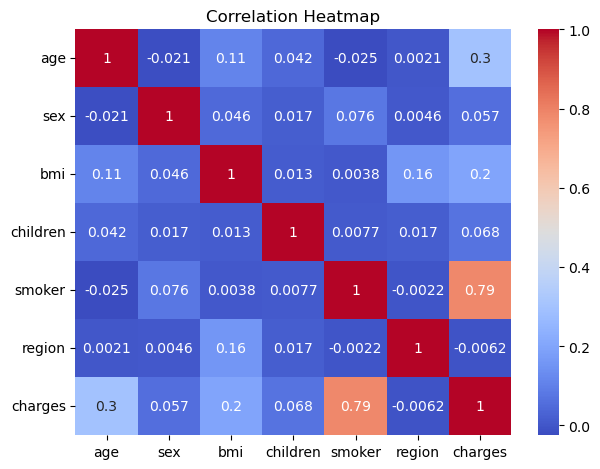

In [201]:
plt.Figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

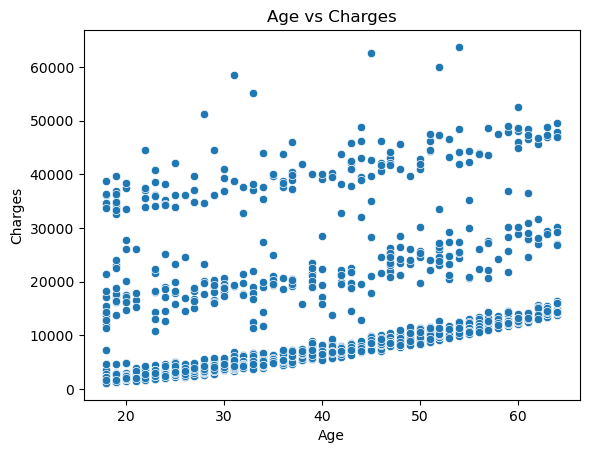

In [202]:
# feature vs target class
plt.Figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', data=df)
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs Charges')
plt.show()

## TODO A3: Feature Preparation (5 Marks)
**You must:**
- Train-test split
- Scaling (if applicable)

**Marks:** Correct split (3), Explanation (2)


In [203]:
# TODO: Prepare features
X= df.drop('charges', axis=1)
y= df['charges']

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

## TODO A4: Multiple Linear Regression (8 Marks)
**You must:**
- Train model
- Evaluate using RMSE, MAE, R²

**Marks:** Model (4), Metrics (4)


In [204]:
# TODO: Multiple Linear Regression
lr= LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred=lr.predict(X_test_scaled)


rmse= np.sqrt(mean_squared_error(y_test, y_pred))
mae= mean_squared_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)

print('RMSE: ', rmse)
print('MAE: ',mae)
print("R^2: ",r2)

RMSE:  5799.587091438359
MAE:  33635210.431178436
R^2:  0.7833463107364537


## TODO A5: Polynomial Regression (7 Marks)
**You must:**
- Apply polynomial features
- Compare with linear regression

**Marks:** Implementation (4), Comparison (3)


In [238]:
# TODO: Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

lr_poly = LinearRegression()
lr_poly.fit(X_poly_train, y_train)

y_pred_poly = lr_poly.predict(X_poly_test)

rmse= np.sqrt(mean_squared_error(y_test, y_pred_poly))
mae= mean_squared_error(y_test, y_pred_poly)
r2= r2_score(y_test, y_pred_poly)

print('RMSE: ', rmse)
print('MAE: ',mae)
print("R^2: ",r2)

RMSE:  4531.071500534039
MAE:  20530608.942951787
R^2:  0.8677566718537749


# Compare ploynomial regression with linear regression
Linear Regression models a straight-line relationship using the original features, making it simple and easy to interpret but limited in capturing complex patterns. Polynomial Regression extends this by adding higher-degree and interaction terms, allowing it to model non-linear relationships more accurately at the cost of increased complexity and risk of overfitting.

## TODO A6: Support Vector Regression (7 Marks)
**You must:**
- Train SVR (RBF kernel)
- Evaluate performance
- Justify kernel choice

**Marks:** Model (4), Justification (3)


In [207]:
# TODO: Support Vector Regression
svr= SVR(kernel='rbf')
svr.fit(X_train, y_train)
y_pred_svr= svr.predict(X_test)

rmse= np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae= mean_squared_error(y_test, y_pred_svr)
r2= r2_score(y_test, y_pred_svr)


print('RMSE: ', rmse)
print('MAE: ',mae)
print("R^2: ",r2)

RMSE:  12902.499468855598
MAE:  166474492.543819
R^2:  -0.07230823043884493


The RBF kernel was chosen because it can effectively capture complex, non-linear relationships in the data by mapping inputs into a higher-dimensional space. This makes it more flexible and accurate than a linear kernel when the decision boundary is not linearly separable.

## TODO A7: Random Forest Regressor (8 Marks)
**You must:**
- Train Random Forest
- Evaluate model

**Marks:** Model (4), Evaluation (4)


In [209]:
# TODO: Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse= np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae= mean_squared_error(y_test, y_pred_rf)
r2= r2_score(y_test, y_pred_rf)


print('RMSE: ', rmse)
print('MAE: ',mae)
print("R^2: ",r2)

RMSE:  4590.5735387944
MAE:  21073365.415079337
R^2:  0.8642606273649586


# 🟠 PART B: Classification Task (45 Marks)
You will work with the provided **classification dataset**.


## TODO B1: Dataset Understanding (5 Marks)
**You must:**
- Load dataset
- Show class distribution
- Comment on imbalance

**Marks:** Analysis (3), Explanation (2)


In [210]:
# TODO: Load classification dataset
df_clf= pd.read_csv('loan_data.csv')
df_clf

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [211]:
df_clf.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


In [212]:
df_clf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [213]:
df_clf.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [214]:
df_clf['loan_status'].value_counts()


loan_status
0    35000
1    10000
Name: count, dtype: int64

The loan dataset is imbalanced, with the majority class containing 35,000 samples and the minority class only 10,000. This imbalance can bias the model toward the majority class, resulting in deceptively high accuracy while performing poorly in identifying the minority class.

## TODO B2: Exploratory Data Analysis (5 Marks)
**You must:**
- Plot class counts
- Plot at least one feature vs class

**Marks:** Plots (5),


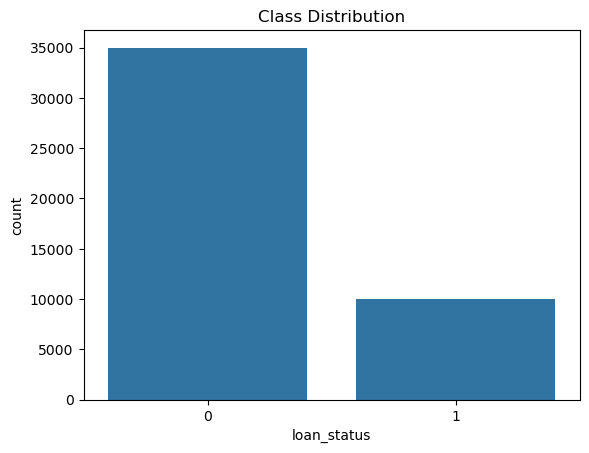

In [215]:
# TODO: Classification EDA
target= df_clf['loan_status']

plt.Figure(figsize=(10, 6))
sns.countplot(x=target, data=df_clf)
plt.title("Class Distribution")
plt.show()

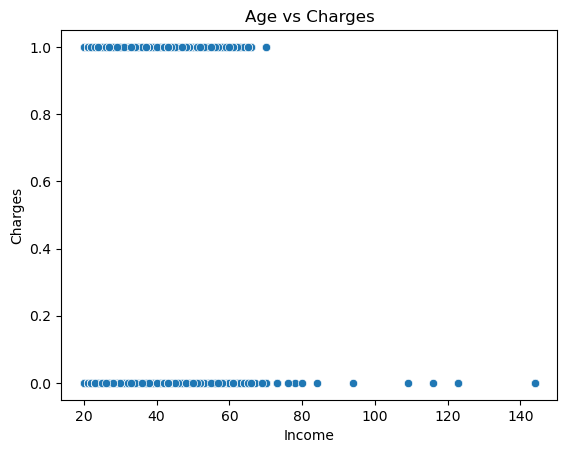

In [216]:
plt.Figure(figsize=(10, 6))
sns.scatterplot(x=df_clf['person_age'], y=target, data=df)
plt.xlabel('Income')
plt.ylabel('Charges')
plt.title('Age vs Charges')
plt.show()

## TODO B3: Feature Preparation (5 Marks)
**You must:**
- Encoding (if needed)
- Scaling
- Train-test split with stratification




In [217]:
print('person_education', df_clf['person_education'].unique())
print('person_home_ownership', df_clf['person_home_ownership'].unique())
print('loan_intent', df_clf['loan_intent'].unique())
print('previous_loan_defaults_on_file', df_clf['previous_loan_defaults_on_file'].unique())

person_education ['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']
person_home_ownership ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
loan_intent ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
previous_loan_defaults_on_file ['No' 'Yes']


In [218]:
# TODO: Prepare classification features
df_clf['person_education']=le.fit_transform(df_clf['person_education'])
df_clf['person_gender']=le.fit_transform(df_clf['person_gender'])
df_clf['person_home_ownership']=le.fit_transform(df_clf['person_home_ownership'])
df_clf['loan_intent']=le.fit_transform(df_clf['loan_intent'])
df_clf['previous_loan_defaults_on_file']=le.fit_transform(df_clf['previous_loan_defaults_on_file'])
df_clf.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1


In [219]:
X= df_clf.drop('loan_status', axis=1)
y= df_clf['loan_status']

X_clf_train, X_clf_test, y_clf_train, y_clf_test=train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_clf_train_scaled= scaler.fit_transform(X_clf_train)
X_clf_test_scaled= scaler.transform(X_clf_test)

## TODO B4: Logistic Regression with L2 (8 Marks)
**You must:**
- Train Logistic Regression
- Evaluate using Accuracy, Precision, Recall
- Show Confusion Matrix

**Marks:** Model (4), Metrics (4)


In [226]:
# TODO: Logistic Regression
lr= LogisticRegression()
lr.fit(X_clf_train_scaled, y_clf_train)

y_clf_pred= lr.predict(X_clf_test_scaled)

print('Accuracy: ', accuracy_score(y_clf_test, y_clf_pred))
print("Precision:", precision_score(y_clf_test, y_clf_pred))
print("Recall:", recall_score(y_clf_test, y_clf_pred))
print(classification_report(y_clf_test, y_clf_pred))

cm=confusion_matrix(y_clf_test, y_clf_pred)
cm

Accuracy:  0.8967777777777778
Precision: 0.777893098079917
Recall: 0.7495
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      7000
           1       0.78      0.75      0.76      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000



array([[6572,  428],
       [ 501, 1499]])

Confusion matrix:
 [[5654 1346]
 [1839  161]]


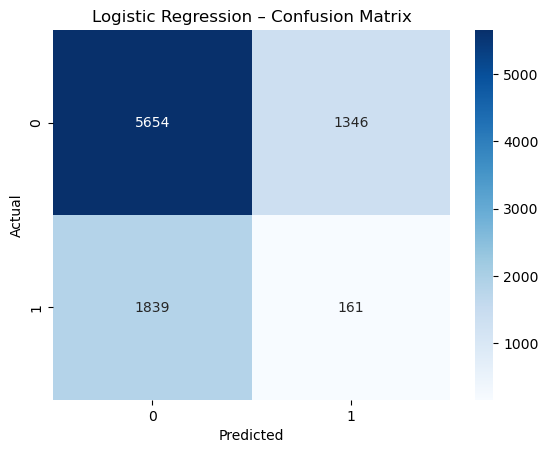

In [221]:
print('Confusion matrix:\n', cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression – Confusion Matrix')
plt.show()

## TODO B5: Support Vector Machine (7 Marks)
**You must:**
- Train SVM (Linear or RBF)
- Evaluate

**Marks:** Model (4), Evaluation (3)


Accuracy:  0.9088888888888889
Precision: 0.8263274336283186
Recall: 0.747
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      7000
           1       0.83      0.75      0.78      2000

    accuracy                           0.91      9000
   macro avg       0.88      0.85      0.86      9000
weighted avg       0.91      0.91      0.91      9000

Confusion matrix:
 [[6686  314]
 [ 506 1494]]


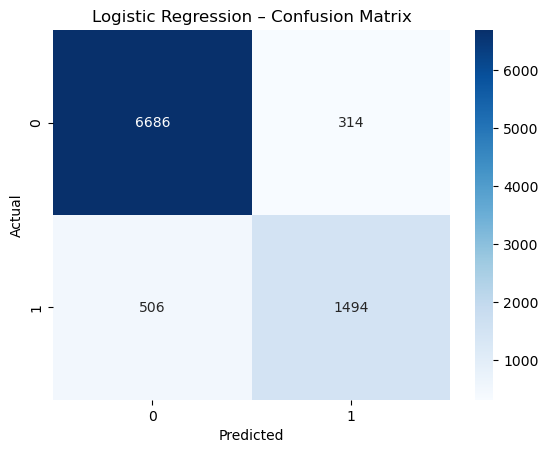

In [ ]:
# TODO: SVM Classification
svm= SVC(kernel='rbf')
svm.fit(X_clf_train_scaled, y_clf_train)
pred_svm= svm.predict(X_clf_test_scaled)

print('Accuracy: ', accuracy_score(y_clf_test, pred_svm))
print('Precision:', precision_score(y_clf_test, pred_svm))
print('Recall:', recall_score(y_clf_test, pred_svm))
print(classification_report(y_clf_test, pred_svm))

cm=confusion_matrix(y_clf_test, pred_svm)
print('Confusion matrix:\n', cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression – Confusion Matrix')
plt.show()

Accuracy:  0.8967777777777778
Precision: 0.7790515893694633
Recall: 0.7475
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      7000
           1       0.78      0.75      0.76      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000

Confusion matrix:
 [[6576  424]
 [ 505 1495]]


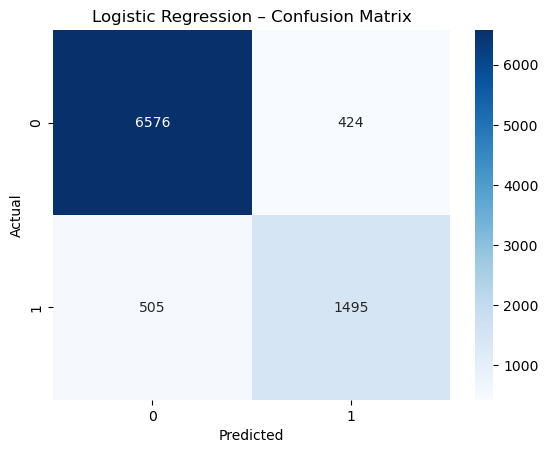

In [239]:
svm= SVC(kernel='linear')
svm.fit(X_clf_train_scaled, y_clf_train)
pred_svm= svm.predict(X_clf_test_scaled)

print('Accuracy: ', accuracy_score(y_clf_test, pred_svm))
print('Precision:', precision_score(y_clf_test, pred_svm))
print('Recall:', recall_score(y_clf_test, pred_svm))
print(classification_report(y_clf_test, pred_svm))

cm=confusion_matrix(y_clf_test, pred_svm)
print('Confusion matrix:\n', cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression – Confusion Matrix')
plt.show()

## TODO B6: Naive Bayes (5 Marks)
**You must:**
- Choose correct NB variant



Accuracy:  0.7363333333333333
Precision:  0.45729333638653535
Recall:  0.9985
              precision    recall  f1-score   support

           0       1.00      0.66      0.80      7000
           1       0.46      1.00      0.63      2000

    accuracy                           0.74      9000
   macro avg       0.73      0.83      0.71      9000
weighted avg       0.88      0.74      0.76      9000



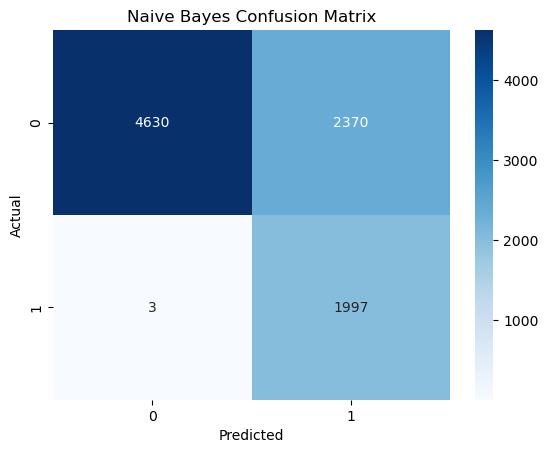

In [230]:
# TODO: Naive Bayes
nb = GaussianNB()
nb.fit(X_clf_train_scaled, y_clf_train)

y_pred_nb = nb.predict(X_clf_test_scaled)
print('Accuracy: ', accuracy_score(y_clf_test, y_pred_nb))
print('Precision: ', precision_score(y_clf_test, y_pred_nb))
print('Recall: ', recall_score(y_clf_test, y_pred_nb))
print(classification_report(y_clf_test, y_pred_nb))

cm_nb = confusion_matrix(y_clf_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

## TODO B7: K-Nearest Neighbors (5 Marks)
**You must:**
- Try multiple K values
- Plot accuracy vs K

**Marks:** Experiment (3), Plot & choice (2)


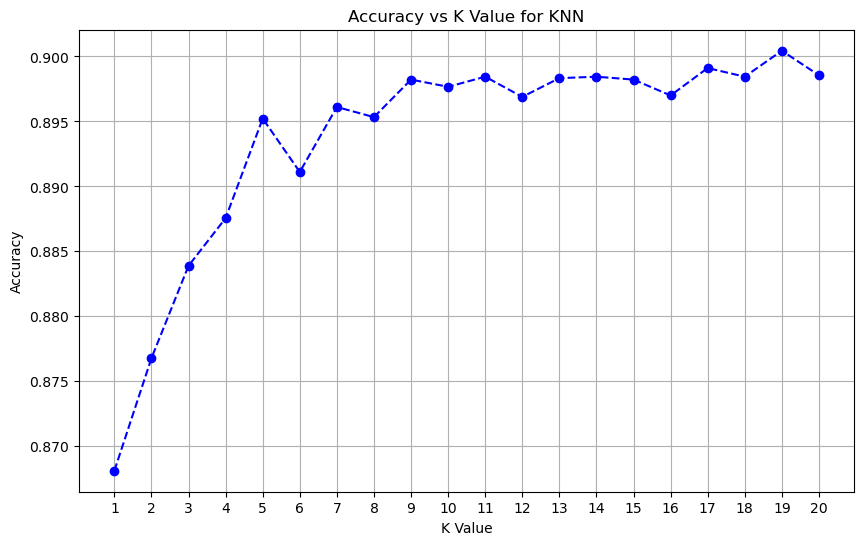

Best K value: 19 with accuracy: 0.9004

Classification Report for best K:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94      7000
           1       0.82      0.71      0.76      2000

    accuracy                           0.90      9000
   macro avg       0.87      0.83      0.85      9000
weighted avg       0.90      0.90      0.90      9000



In [233]:
# TODO: KNN

k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_clf_train_scaled, y_clf_train)
    y_pred_knn = knn.predict(X_clf_test_scaled)
    accuracies.append(accuracy_score(y_clf_test, y_pred_knn))

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='--', color='b')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K Value for KNN')
plt.xticks(k_values)
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f"Best K value: {best_k} with accuracy: {max(accuracies):.4f}")

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_clf_train_scaled, y_clf_train)
y_pred_best_knn = knn_best.predict(X_clf_test_scaled)
print("\nClassification Report for best K:\n", classification_report(y_clf_test, y_pred_best_knn))

## TODO B8: Random Forest Classifier (5 Marks)
**You must:**
- Train model
- Show feature importance

**Marks:** Model (3), Interpretation (2)



========== Classification Report==========

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7000
           1       0.89      0.77      0.82      2000

    accuracy                           0.93      9000
   macro avg       0.91      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



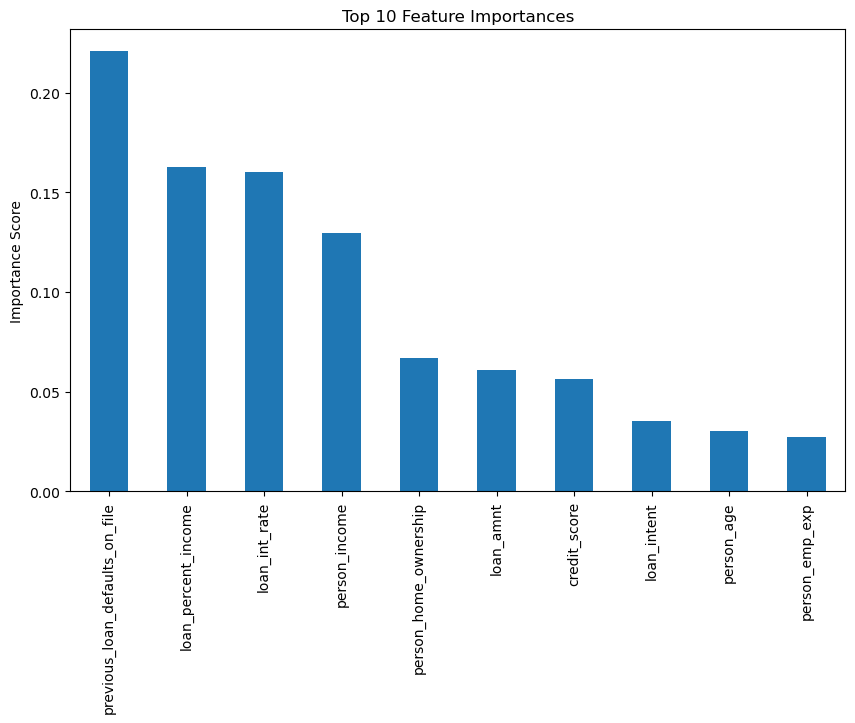

In [235]:
# TODO: Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_clf_train_scaled, y_clf_train)

pred_rf= rf.predict(X_clf_test_scaled)

print('\n========== Classification Report==========\n')
print(classification_report(y_clf_test, pred_rf))

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances")
plt.ylabel("Importance Score")
plt.show()

# 🧠 Final Reflection (5 Marks)
**Answer briefly:**
- Best regression model and why
- Best classification model and why
- One real-world deployment scenario


## TODO: Write your reflection here

1.  The best regression model is Polynomial Regression. It achive the height R^2 value of 86.77%

2. The best classification model is Random Forest Regressor. Because it naturally handles non-linear relationships and achive the height accuracy of 93%.

3. The classification model can be deployed as an automated Loan Approval Decision System in a bank. When a user applies for a loan online, their details (income, credit score, intent) are passed to the model. The model instantly predicts the risk of default (Yes/No), allowing the bank to either automatically approve low-risk loans or flag high-risk applications for manual review.